<a href="https://colab.research.google.com/github/KallyaniKalesh/TimesFM/blob/main/TimesFM_Covariates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import timesfm
import databento as db
import json
import numpy as np
import pandas as pd
from alpha_vantage.timeseries import TimeSeries
import warnings
warnings.filterwarnings("ignore")

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0].


In [ ]:
!pip -q install databento
!pip -q install timesfm
!pip -q install alpha_vantage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00


In [ ]:
config = {
    "alpha_vantage": {
        "key": "demo", # you can use the demo API key for this project, but please make sure to get your own API key at https://www.alphavantage.co/support/#api-key
        "symbol": "GBTC",
        "outputsize": "full",
        "key_adjusted_close": "4. close",
    }
}

In [ ]:
ts = TimeSeries(key='IMS21UGWUFNMWBMD') #CHANGE THIS API KEY TO YOUR OWN
data, meta_data = ts.get_daily("GBTC", outputsize="full")

alpha_df = pd.DataFrame(data).T
alpha_df.reset_index(inplace=True)
alpha_df.columns = ["ds", "open", "high", "low", "close", "volume"]
alpha_df["ds"] = pd.to_datetime(alpha_df["ds"])
alpha_df["close"] = alpha_df["close"].astype(float)
alpha_df = alpha_df.rename(columns = {"close": "y"})
alpha_df["unique_id"] = 1
alpha_df = alpha_df[["unique_id", "ds", "y"]]
alpha_df = alpha_df.sort_values(by="ds")


In [ ]:
btc_ts = TimeSeries(key='IMS21UGWUFNMWBMD') #CHANGE THIS API KEY TO YOUR OWN
btc_data, btc_meta_data = ts.get_daily("BTC", outputsize="full")
btc_df = pd.DataFrame(data).T
btc_df.reset_index(inplace=True)
btc_df.columns = ["ds", "open", "high", "low", "close", "volume"]
btc_df["ds"] = pd.to_datetime(btc_df["ds"])
btc_df["close"] = btc_df["close"].astype(float)
btc_df = btc_df.rename(columns = {"close": "y"})
btc_df["unique_id"] = 1
btc_df = btc_df[["unique_id", "ds", "y"]]
btc_df = btc_df.sort_values(by="ds")

In [ ]:
btc_df

,unique_id,ds,y
2476,1,2015-05-04,42.00
2475,1,2015-05-05,55.00
2474,1,2015-05-06,55.00
2473,1,2015-05-07,40.00
2472,1,2015-05-08,49.00
...,...,...,...
4,1,2025-03-03,68.03
3,1,2025-03-04,68.74
2,1,2025-03-05,71.56
1,1,2025-03-06,70.44


In [ ]:
alpha_df

,unique_id,ds,y
2476,1,2015-05-04,42.00
2475,1,2015-05-05,55.00
2474,1,2015-05-06,55.00
2473,1,2015-05-07,40.00
2472,1,2015-05-08,49.00
...,...,...,...
4,1,2025-03-03,68.03
3,1,2025-03-04,68.74
2,1,2025-03-05,71.56
1,1,2025-03-06,70.44


In [ ]:
alpha_df = alpha_df[pd.DatetimeIndex(alpha_df['ds']).year > 2022]
btc_df = btc_df[pd.DatetimeIndex(btc_df['ds']).year > 2022]

<Axes: xlabel='ds'>

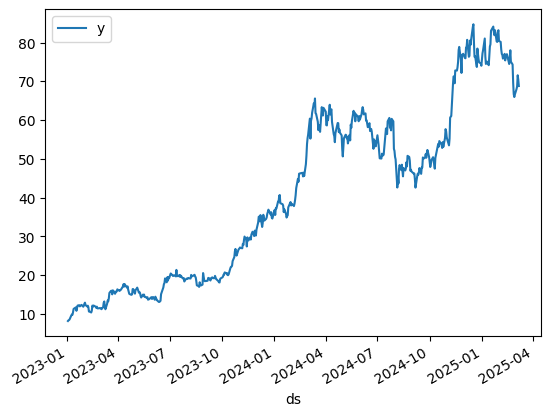

In [ ]:
alpha_df.plot(x="ds", y="y")

<Axes: xlabel='ds'>

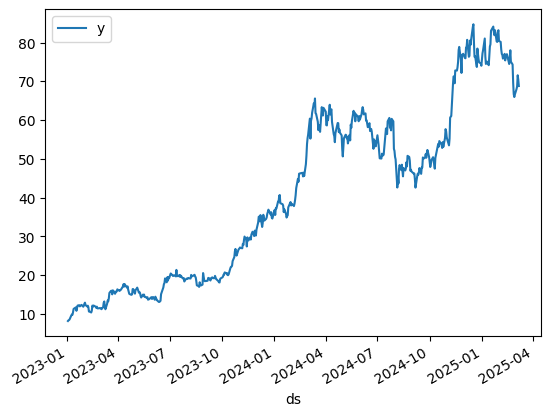

In [ ]:
btc_df.plot(x="ds",y="y")

In [ ]:
forecast_length = 32

In [ ]:
#Alpha Vantage
train_df = alpha_df[:-1*forecast_length]
test_df = alpha_df[-1*forecast_length:]
print(train_df.shape, test_df.shape)

(514, 3) (32, 3)


In [ ]:
tfm = timesfm.TimesFm(
      hparams=timesfm.TimesFmHparams(
          backend="cpu",
          per_core_batch_size=32,
          horizon_len=forecast_length,
          num_layers=50,
          use_positional_embedding=False,
          context_len=512,
      ),
      checkpoint=timesfm.TimesFmCheckpoint(
          huggingface_repo_id="google/timesfm-2.0-500m-pytorch"),
  )

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

.gitattributes:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

torch_model.ckpt:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

In [ ]:
train_df.shape

(514, 3)

In [ ]:
forecast_input = [list(train_df['y'])]

In [ ]:
dynamic_numerical_covariates = {
    'BTC_price': [btc_df['y'].tolist()]

}

In [ ]:
test_forecast, _ = tfm.forecast_with_covariates(
    forecast_input,
    dynamic_numerical_covariates = dynamic_numerical_covariates,
    freq=[0] * len(forecast_input),
      xreg_mode="xreg + timesfm",              # default
      ridge=0.0,
      force_on_cpu=False,
      normalize_xreg_target_per_input=True
)

In [ ]:
test_forecast = np.array(test_forecast[0])

In [ ]:
print(test_forecast)

[82.69349  81.899994 83.106735 80.22417  80.10797  82.5491   83.15889
 80.3658   80.124146 78.153    76.99185  76.710724 75.791336 77.021
 75.36111  76.78586  76.20146  76.97064  74.48547  76.07468  77.96486
 75.03461  74.31769  69.59494  66.71415  65.93492  66.54521  68.023476
 68.75148  71.58636  70.415726 68.73071 ]


In [ ]:
test_df['forecast'] = test_forecast

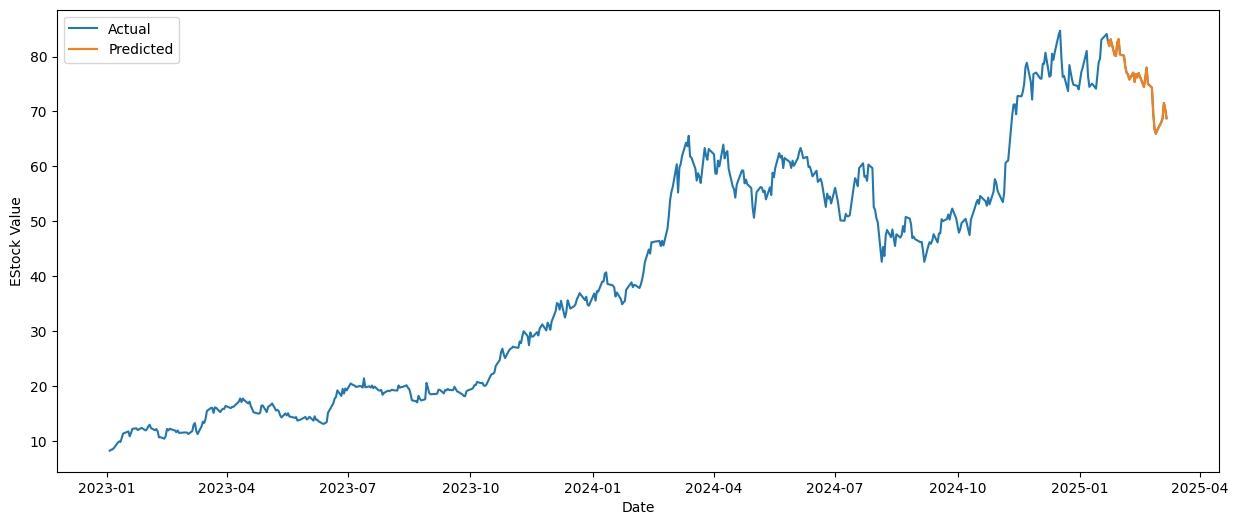

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(alpha_df["ds"], alpha_df["y"], label="Actual")
plt.plot(test_df["ds"], test_df["forecast"], label="Predicted")
plt.ylabel('EStock Value')
plt.xlabel('Date')
plt.legend()
plt.show()

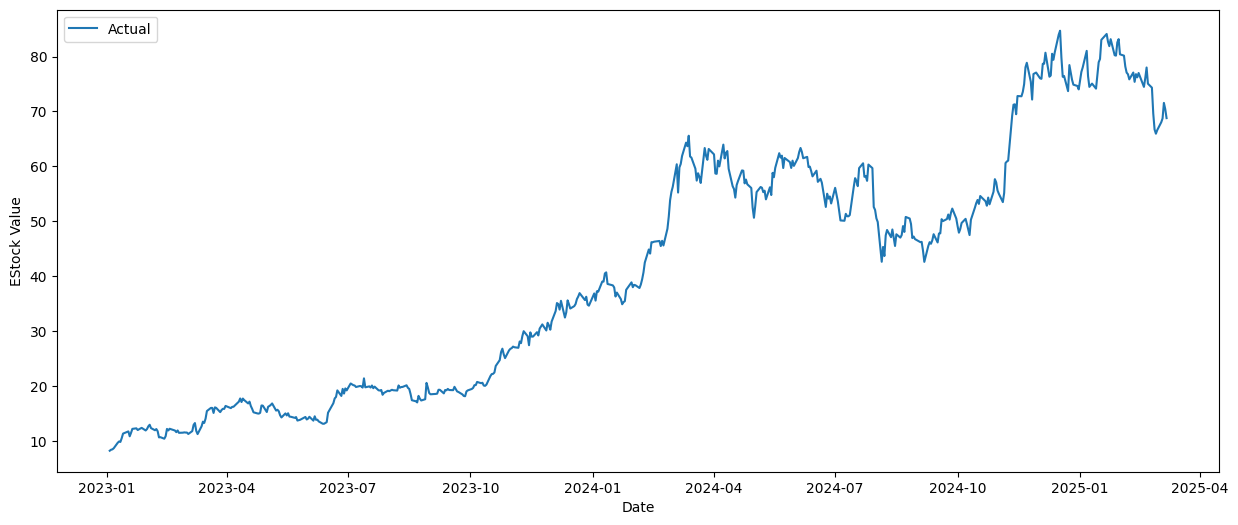

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(alpha_df["ds"], alpha_df["y"], label="Actual")
#plt.plot(test_df["ds"], test_df["forecast"], label="Predicted")
plt.ylabel('EStock Value')
plt.xlabel('Date')
plt.legend()
plt.show()